# MultiNicheNet for PLA vs platelet-free cells

In [ ]:
# git clone https://github.com/saeyslab/multinichenetr.git
# R CMD INSTALL multinichenetr

In [9]:
library(Seurat)
library(SingleCellExperiment)
library(SummarizedExperiment)
library(dplyr)
library(tidyr)
library(tibble)
library(ggplot2)
library(multinichenetr)
library(nichenetr)

set.seed(123)


Attaching package: ‘nichenetr’


The following objects are masked from ‘package:multinichenetr’:

    combine_sender_receiver_de, generate_prioritization_tables




In [2]:
out_dir <- "/nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs/multinichenet"
plot_dir <- file.path(out_dir, "plots")
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(plot_dir, recursive = TRUE, showWarnings = FALSE)

## 1. Load your Seurat object

Change `file_name` if you want to run this on another gated dataset.

In [3]:
data_path <- "/nfs/home/students/i.kaciran/FoPra_PLAs/data/datasets/"

# Choose dataset
# file_name <- "gated_ImmuneAging.rds"
# file_name <- "gated_heart_processed.rds"
file_name <- "gated_sepsis_processed.rds"
# file_name <- "gated_vaccine_processed.rds"
# file_name <- "gated_our_dataset_processed.rds"

seurat_obj <- readRDS(file.path(data_path, file_name))
DefaultAssay(seurat_obj) <- "RNA"

# Quick metadata checks
colnames(seurat_obj@meta.data)
table(seurat_obj$pla_status, useNA = "ifany")
table(seurat_obj$lineage, seurat_obj$pla_status, useNA = "ifany")

[1] "orig.ident"                             
 [2] "nCount_RNA"                             
 [3] "nFeature_RNA"                           
 [4] "nCount_ADT"                             
 [5] "nFeature_ADT"                           
 [6] "sample"                                 
 [7] "donor_id"                               
 [8] "cell_barcodes"                          
 [9] "scRNA.seq"                              
[10] "TCR"                                    
[11] "BCR"                                    
[12] "CITE.seq"                               
[13] "Bulk.RNA.seq"                           
[14] "Olink.proteomics"                       
[15] "Gender"                                 
[16] "Age"                                    
[17] "Sample.Collection.Date"                 
[18] "Sample.Collection.Site"                 
[19] "Group"                                  
[20] "Sepsis.Infection.Source"                
[21] "Ethnicity"                              
[22] "Chronic.comorbidity.None"               
[23] "Cardiovascular.compromise"              
[24] "COPD"                                   
[25] "Hypertension"                           
[26] "Diabetes"                               
[27] "Respiratory.insufficiency"              
[28] "Renal.insufficiency"                    
[29] "Tuberculosis"                           
[30] "Length.of.ICU.stay.days"                
[31] "Length.of.hospital.stay.days"           
[32] "X14.day.mortality..Deceased.1.Living.0."
[33] "X28.day.mortality..Deceased.1.Living.0."
[34] "X90.day.mortality..Deceased.1.Living.0."
[35] "Gram.positive.bacteria"                 
[36] "Gram.negative.bacteria"                 
[37] "Virus"                                  
[38] "Fungi"                                  
[39] "Microbiology.laboratory..Unknown"       
[40] "SOFA.score"                             
[41] "Shock"                                  
[42] "Organ.failure"                          
[43] "Mechanical.ventilation"                 
[44] "percent.mt"                             
[45] "percent.ribo"                           
[46] "percent.hb"                             
[47] "mt_outlier_all"                         
[48] "is_outlier_RNA"                         
[49] "is_outlier_protein"                     
[50] "is_outlier"                             
[51] "scDblFinder.class"                      
[52] "scDblFinder.score"                      
[53] "RNA_snn_res.0.8"                        
[54] "seurat_clusters"                        
[55] "RNA_snn_res.0.25"                       
[56] "RNA.weight"                             
[57] "ADT.weight"                             
[58] "leiden_0.8_totalVI"                     
[59] "leiden_0.25_totalVI"                    
[60] "celltype_full"                          
[61] "lineage"                                
[62] "pla_status"                             
[63] "celltype"


          PLA platelet-free 
        39405        245638 

             
                 PLA platelet-free
  DCs           2298          3440
  NK cells      2443         31768
  Unassigned       0        117212
  neutrophils      0          4210
  CD8 T cells   7504         19400
  B cells        488         20788
  CD4 T cells   5680         45049
  Monocytes    20992          3479
  <NA>             0           292

## 2. Prepare a smaller Seurat object for MultiNicheNet

In [4]:
seurat_mnn <- seurat_obj

# Missing PLA labels are platelet-free in your setup
seurat_mnn$pla_status[is.na(seurat_mnn$pla_status)] <- "platelet-free"

# Keep only RNA assay to reduce memory
DefaultAssay(seurat_mnn) <- "RNA"
seurat_mnn <- DietSeurat(
  seurat_mnn,
  assays = "RNA",
  counts = TRUE,
  data = TRUE,
  scale.data = FALSE,
  dimreducs = NULL,
  graphs = NULL
)

table(seurat_mnn$lineage, seurat_mnn$pla_status)

Warning message:
“The `counts` argument of `DietSeurat()` is deprecated as of Seurat 5.0.0.
ℹ Please use the `layers` argument instead.”
Warning message:
“The `data` argument of `DietSeurat()` is deprecated as of Seurat 5.0.0.
ℹ Please use the `layers` argument instead.”
Warning message:
“The `scale.data` argument of `DietSeurat()` is deprecated as of Seurat 5.0.0.
ℹ Please use the `layers` argument instead.”


             
                 PLA platelet-free
  DCs           2298          3440
  NK cells      2443         31768
  Unassigned       0        117212
  neutrophils      0          4210
  CD8 T cells   7504         19400
  B cells        488         20788
  CD4 T cells   5680         45049
  Monocytes    20992          3479

## 3. Create MultiNicheNet-compatible metadata

`sample_mnn = sample + pla_status`

The original `donor_id` is used as a paired covariate in the DE model.

In [5]:
# Create condition-specific sample ID
seurat_mnn$sample_mnn <- paste(
  seurat_mnn$sample,
  seurat_mnn$pla_status,
  sep = "_"
)

# Make column values syntactically valid
seurat_mnn$sample_mnn <- make.names(seurat_mnn$sample_mnn)
seurat_mnn$sample <- make.names(seurat_mnn$sample)
seurat_mnn$donor_id <- make.names(seurat_mnn$donor_id)
seurat_mnn$lineage <- make.names(seurat_mnn$lineage)
seurat_mnn$pla_status <- make.names(seurat_mnn$pla_status)

# After make.names(), "platelet-free" becomes "platelet.free"
table(seurat_mnn$pla_status)

# Check that each sample_mnn belongs to one condition only
sample_condition_check <- seurat_mnn@meta.data %>%
  distinct(sample_mnn, pla_status) %>%
  count(sample_mnn) %>%
  filter(n > 1)

if (nrow(sample_condition_check) > 0) {
  stop("Some sample_mnn values belong to more than one condition.")
}

# Check paired availability per donor
seurat_mnn@meta.data %>%
  distinct(donor_id, pla_status) %>%
  count(donor_id) %>%
  count(n)


          PLA platelet.free 
        39405        245638 

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


n,nn
<int>,<int>
2,40


## 4. Convert Seurat to SingleCellExperiment and harmonize gene names

In [6]:
sce <- Seurat::as.SingleCellExperiment(seurat_mnn, assay = "RNA")

# Update aliases to official human symbols and make valid R names
sce <- alias_to_symbol_SCE(sce, "human") %>%
  makenames_SCE()

# Metadata sanity checks
colnames(colData(sce))
table(colData(sce)$pla_status)
table(colData(sce)$lineage, colData(sce)$pla_status)

Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


[1] "there are provided symbols that are not in the alias annotation table: "
    [1] "ENSG00000260179"  "ENSG00000234396"  "ENSG00000228037" 
    [4] "ENSG00000284616"  "ENSG00000238260"  "ENSG00000260972" 
    [7] "ENSG00000270035"  "ENSG00000284646"  "ENSG00000284739" 
   [10] "ENSG00000272235"  "ENSG00000284694"  "ENSG00000287356" 
   [13] "ENSG00000224387"  "ENSG00000285629"  "ENSG00000272161" 
   [16] "ENSG00000287727"  "ENSG00000223989"  "ENSG00000228423" 
   [19] "ENSG00000286448"  "ENSG00000237365"  "ENSG00000284703" 
   [22] "ENSG00000241326"  "ENSG00000285701"  "ENSG00000233645" 
   [25] "ENSG00000284708"  "ENSG00000235146"  "ENSG00000236601" 
   [28] "ENSG00000228150"  "ENSG00000229393"  "ENSG00000269978" 
   [31] "ENSG00000287586"  "ENSG00000227169"  "ENSG00000272482" 
   [34] "ENSG00000284747"  "ENSG00000238290"  "ENSG00000225387" 
   [37] "ENSG00000288398"  "ENSG00000224621"  "ENSG00000285833" 
   [40] "ENSG00000284692"  "ENSG00000284745"  "ENSG00000225952" 
   [43] "ENS

[1] "orig.ident"                             
 [2] "nCount_RNA"                             
 [3] "nFeature_RNA"                           
 [4] "nCount_ADT"                             
 [5] "nFeature_ADT"                           
 [6] "sample"                                 
 [7] "donor_id"                               
 [8] "cell_barcodes"                          
 [9] "scRNA.seq"                              
[10] "TCR"                                    
[11] "BCR"                                    
[12] "CITE.seq"                               
[13] "Bulk.RNA.seq"                           
[14] "Olink.proteomics"                       
[15] "Gender"                                 
[16] "Age"                                    
[17] "Sample.Collection.Date"                 
[18] "Sample.Collection.Site"                 
[19] "Group"                                  
[20] "Sepsis.Infection.Source"                
[21] "Ethnicity"                              
[22] "Chronic.comorbidity.None"               
[23] "Cardiovascular.compromise"              
[24] "COPD"                                   
[25] "Hypertension"                           
[26] "Diabetes"                               
[27] "Respiratory.insufficiency"              
[28] "Renal.insufficiency"                    
[29] "Tuberculosis"                           
[30] "Length.of.ICU.stay.days"                
[31] "Length.of.hospital.stay.days"           
[32] "X14.day.mortality..Deceased.1.Living.0."
[33] "X28.day.mortality..Deceased.1.Living.0."
[34] "X90.day.mortality..Deceased.1.Living.0."
[35] "Gram.positive.bacteria"                 
[36] "Gram.negative.bacteria"                 
[37] "Virus"                                  
[38] "Fungi"                                  
[39] "Microbiology.laboratory..Unknown"       
[40] "SOFA.score"                             
[41] "Shock"                                  
[42] "Organ.failure"                          
[43] "Mechanical.ventilation"                 
[44] "percent.mt"                             
[45] "percent.ribo"                           
[46] "percent.hb"                             
[47] "mt_outlier_all"                         
[48] "is_outlier_RNA"                         
[49] "is_outlier_protein"                     
[50] "is_outlier"                             
[51] "scDblFinder.class"                      
[52] "scDblFinder.score"                      
[53] "RNA_snn_res.0.8"                        
[54] "seurat_clusters"                        
[55] "RNA_snn_res.0.25"                       
[56] "RNA.weight"                             
[57] "ADT.weight"                             
[58] "leiden_0.8_totalVI"                     
[59] "leiden_0.25_totalVI"                    
[60] "celltype_full"                          
[61] "lineage"                                
[62] "pla_status"                             
[63] "celltype"                               
[64] "sample_mnn"                             
[65] "ident"


          PLA platelet.free 
        39405        245638 

             
                 PLA platelet.free
  B.cells        488         20788
  CD4.T.cells   5680         45049
  CD8.T.cells   7504         19400
  DCs           2298          3440
  Monocytes    20992          3479
  NA.              0           292
  neutrophils      0          4210
  NK.cells      2443         31768
  Unassigned       0        117212

## 5. Load NicheNet v2 networks

This downloads the ligand-receptor network and ligand-target matrix used by MultiNicheNet/NicheNet.
The files are cached locally after the first download.

In [10]:
organism <- "human"
options(timeout = 600)

resource_dir <- file.path(out_dir, "resources")
dir.create(resource_dir, recursive = TRUE, showWarnings = FALSE)

lr_network_path <- file.path(resource_dir, "lr_network_human_allInfo_30112033.rds")
lt_matrix_path <- file.path(resource_dir, "ligand_target_matrix_nsga2r_final.rds")

if (!file.exists(lr_network_path)) {
  download.file(
    "https://zenodo.org/record/10229222/files/lr_network_human_allInfo_30112033.rds",
    lr_network_path,
    mode = "wb"
  )
}

if (!file.exists(lt_matrix_path)) {
  download.file(
    "https://zenodo.org/record/7074291/files/ligand_target_matrix_nsga2r_final.rds",
    lt_matrix_path,
    mode = "wb"
  )
}

lr_network_all <- readRDS(lr_network_path) %>%
  mutate(
    ligand = convert_alias_to_symbols(ligand, organism = organism),
    receptor = convert_alias_to_symbols(receptor, organism = organism),
    ligand = make.names(ligand),
    receptor = make.names(receptor)
  )

lr_network <- lr_network_all %>%
  distinct(ligand, receptor)

ligand_target_matrix <- readRDS(lt_matrix_path)

colnames(ligand_target_matrix) <- colnames(ligand_target_matrix) %>%
  convert_alias_to_symbols(organism = organism) %>%
  make.names()

rownames(ligand_target_matrix) <- rownames(ligand_target_matrix) %>%
  convert_alias_to_symbols(organism = organism) %>%
  make.names()

lr_network <- lr_network %>%
  filter(ligand %in% colnames(ligand_target_matrix))

ligand_target_matrix <- ligand_target_matrix[, unique(lr_network$ligand)]

dim(lr_network)
dim(ligand_target_matrix)

[1] "following are the official gene symbols of input aliases: "
  symbol alias
1  YARS1  YARS
[1] "all input symbols were official symbols"
[1] "all input symbols were official symbols"
[1] "all input symbols were official symbols"


[1] 5073    2

[1] 33354  1226

## 6. Define MultiNicheNet settings

We compare both directions:

- `PLA-platelet.free`
- `platelet.free-PLA`

The first one is the main contrast of interest for PLA-up communication.

In [11]:
sample_id <- "sample_mnn"
group_id <- "pla_status"
celltype_id <- "lineage"

conditions_keep <- c("platelet.free", "PLA")

# Paired design: donor_id adjusts for donor/sample pairing in the DE model
covariates <- "donor_id"
batches <- NA

contrasts_oi <- c("'PLA-platelet.free','platelet.free-PLA'")

contrast_tbl <- tibble(
  contrast = c("PLA-platelet.free", "platelet.free-PLA"),
  group = c("PLA", "platelet.free")
)

sce <- sce[, SummarizedExperiment::colData(sce)[, group_id] %in% conditions_keep]

senders_oi <- SummarizedExperiment::colData(sce)[, celltype_id] %>%
  unique() %>%
  as.character()

receivers_oi <- SummarizedExperiment::colData(sce)[, celltype_id] %>%
  unique() %>%
  as.character()

sce <- sce[, SummarizedExperiment::colData(sce)[, celltype_id] %in% union(senders_oi, receivers_oi)]

table(SummarizedExperiment::colData(sce)[, group_id])
table(SummarizedExperiment::colData(sce)[, celltype_id], SummarizedExperiment::colData(sce)[, group_id])


          PLA platelet.free 
        39405        245638 

             
                 PLA platelet.free
  B.cells        488         20788
  CD4.T.cells   5680         45049
  CD8.T.cells   7504         19400
  DCs           2298          3440
  Monocytes    20992          3479
  NA.              0           292
  neutrophils      0          4210
  NK.cells      2443         31768
  Unassigned       0        117212

## 7. Cell-type filtering

Start with `min_cells = 10`. If too many lineages are filtered out, rerun from here with `min_cells = 5`.

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the multinichenetr package.
  Please report the issue at
  <https://github.com/browaeysrobin/multinichenetr/issues>.”


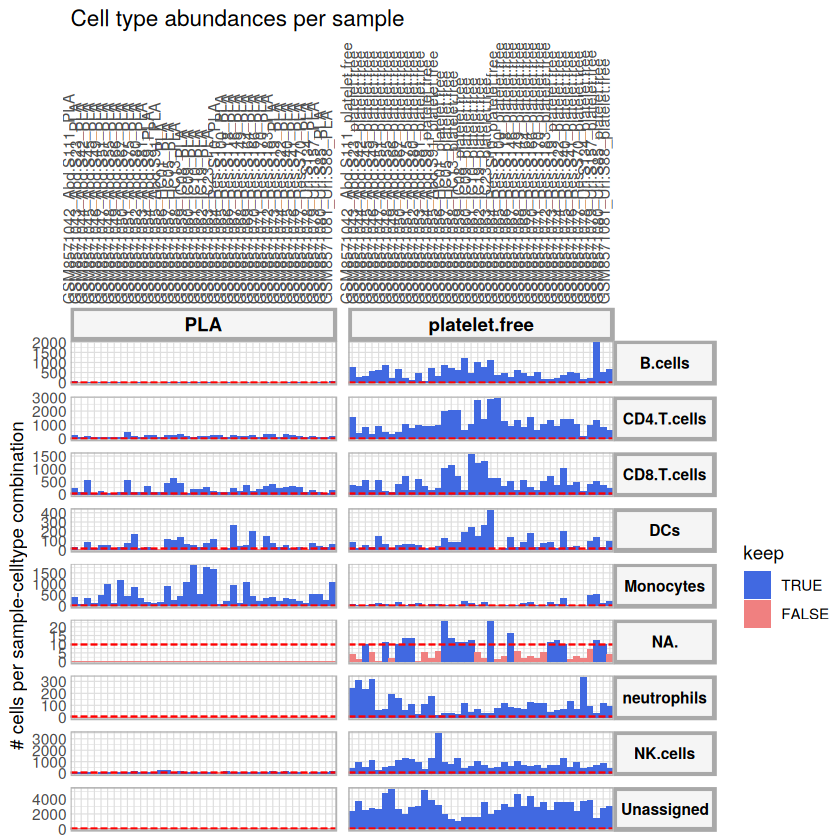

In [ ]:
min_cells <- 10

abundance_info <- get_abundance_info(
  sce = sce,
  sample_id = sample_id,
  group_id = group_id,
  celltype_id = celltype_id,
  min_cells = min_cells,
  senders_oi = senders_oi,
  receivers_oi = receivers_oi,
  batches = batches
)

p_abundance <- abundance_info$abund_plot_sample
p_abundance

ggsave(
  file.path(plot_dir, "multinichenet_abundance_plot_sample.png"),
  p_abundance,
  width = 10,
  height = 7
)

### Remove absent and condition-specific cell types

For the main PLA vs platelet-free comparison, we keep only lineages sufficiently present in both conditions.

In [14]:
abundance_df_summarized <- abundance_info$abundance_data %>%
  ungroup() %>%
  mutate(
    keep = as.character(keep),
    keep = keep == "TRUE"
  ) %>%
  group_by(group_id, celltype_id) %>%
  summarise(
    samples_present = sum(keep, na.rm = TRUE),
    .groups = "drop"
  )

condition_specific_celltypes <- abundance_df_summarized %>%
  group_by(celltype_id) %>%
  summarise(
    min_samples_present = min(samples_present),
    max_samples_present = max(samples_present),
    .groups = "drop"
  ) %>%
  filter(
    min_samples_present < 2,
    max_samples_present >= 2
  ) %>%
  pull(celltype_id)

absent_celltypes <- abundance_df_summarized %>%
  group_by(celltype_id) %>%
  summarise(
    max_samples_present = max(samples_present),
    .groups = "drop"
  ) %>%
  filter(max_samples_present < 2) %>%
  pull(celltype_id)

message("Condition-specific celltypes:")
print(condition_specific_celltypes)

message("Absent/too rare in all conditions:")
print(absent_celltypes)

analyse_condition_specific_celltypes <- FALSE

if (analyse_condition_specific_celltypes) {
  senders_oi <- setdiff(senders_oi, absent_celltypes)
  receivers_oi <- setdiff(receivers_oi, absent_celltypes)
} else {
  remove_celltypes <- union(absent_celltypes, condition_specific_celltypes)
  senders_oi <- setdiff(senders_oi, remove_celltypes)
  receivers_oi <- setdiff(receivers_oi, remove_celltypes)
}

sce <- sce[, SummarizedExperiment::colData(sce)[, celltype_id] %in% union(senders_oi, receivers_oi)]

message("Final sender celltypes:")
print(senders_oi)

message("Final receiver celltypes:")
print(receivers_oi)

table(SummarizedExperiment::colData(sce)[, celltype_id], SummarizedExperiment::colData(sce)[, group_id])

Condition-specific celltypes:



[1] "NA."         "Unassigned"  "neutrophils"


Absent/too rare in all conditions:



character(0)


Final sender celltypes:



[1] "B.cells"     "CD4.T.cells" "CD8.T.cells" "NK.cells"    "Monocytes"  
[6] "DCs"        


Final receiver celltypes:



[1] "B.cells"     "CD4.T.cells" "CD8.T.cells" "NK.cells"    "Monocytes"  
[6] "DCs"        


             
                PLA platelet.free
  B.cells       488         20788
  CD4.T.cells  5680         45049
  CD8.T.cells  7504         19400
  DCs          2298          3440
  Monocytes   20992          3479
  NK.cells     2443         31768

## 8. Gene filtering

In [15]:
min_sample_prop <- 0.50
fraction_cutoff <- 0.05

frq_list <- get_frac_exprs(
  sce = sce,
  sample_id = sample_id,
  celltype_id = celltype_id,
  group_id = group_id,
  batches = batches,
  min_cells = min_cells,
  fraction_cutoff = fraction_cutoff,
  min_sample_prop = min_sample_prop
)

genes_oi <- frq_list$expressed_df %>%
  filter(expressed == TRUE) %>%
  pull(gene) %>%
  unique()

length(genes_oi)

sce <- sce[genes_oi, ]

Joining with `by = join_by(sample, group)`


[1] "Samples are considered if they have more than 10 cells of the cell type of interest"


Joining with `by = join_by(sample, celltype)`


[1] "Genes with non-zero counts in at least 5% of cells of a cell type of interest in a particular sample will be considered as expressed in that sample."
[1] "Genes expressed in at least 12 samples will considered as expressed in the cell type: B.cells"
[1] "Genes expressed in at least 20 samples will considered as expressed in the cell type: CD4.T.cells"
[1] "Genes expressed in at least 20 samples will considered as expressed in the cell type: CD8.T.cells"
[1] "Genes expressed in at least 17.5 samples will considered as expressed in the cell type: DCs"
[1] "Genes expressed in at least 18 samples will considered as expressed in the cell type: Monocytes"
[1] "Genes expressed in at least 18 samples will considered as expressed in the cell type: NK.cells"


Joining with `by = join_by(sample)`
Joining with `by = join_by(celltype)`
Joining with `by = join_by(sample, celltype, group)`


[1] "9055 genes are considered as expressed in the cell type: B.cells"
[1] "8061 genes are considered as expressed in the cell type: CD4.T.cells"
[1] "8029 genes are considered as expressed in the cell type: CD8.T.cells"
[1] "9468 genes are considered as expressed in the cell type: DCs"
[1] "8767 genes are considered as expressed in the cell type: Monocytes"
[1] "8684 genes are considered as expressed in the cell type: NK.cells"


[1] 10519

## 9. Pseudobulk expression calculation

In [16]:
abundance_expression_info <- process_abundance_expression_info(
  sce = sce,
  sample_id = sample_id,
  group_id = group_id,
  celltype_id = celltype_id,
  min_cells = min_cells,
  senders_oi = senders_oi,
  receivers_oi = receivers_oi,
  lr_network = lr_network,
  batches = batches,
  frq_list = frq_list,
  abundance_info = abundance_info
)

head(abundance_expression_info$celltype_info$pb_df)
head(abundance_expression_info$sender_receiver_info$pb_df)

Joining with `by = join_by(sender, receiver, ligand, receptor)`
Joining with `by = join_by(sender, receiver, ligand, receptor)`
Joining with `by = join_by(sender, receiver, ligand, receptor)`


gene,sample,pb_sample,celltype
<chr>,<chr>,<dbl>,<fct>
A1BG.AS1,GSM8571042_Abd.S111_PLA,0.000000,B.cells
AAAS,GSM8571042_Abd.S111_PLA,5.914249,B.cells
AAGAB,GSM8571042_Abd.S111_PLA,4.627766,B.cells
AAK1,GSM8571042_Abd.S111_PLA,5.341199,B.cells
AAMDC,GSM8571042_Abd.S111_PLA,4.627766,B.cells
AAMP,GSM8571042_Abd.S111_PLA,5.475463,B.cells


sample,sender,receiver,ligand,receptor,pb_ligand,pb_receptor,ligand_receptor_pb_prod
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
GSM8571059_IC08_PLA,NK.cells,Monocytes,S100A8,ITGB2,16.19270,11.09630,179.6790
GSM8571070_Res.S166_PLA,Monocytes,Monocytes,S100A8,ITGB2,16.54113,10.78204,178.3472
GSM8571060_IC09_PLA,Monocytes,NK.cells,S100A8,ITGB2,16.07450,10.97502,176.4180
GSM8571059_IC08_PLA,NK.cells,Monocytes,S100A9,ITGB2,15.89681,11.09630,176.3958
GSM8571059_IC08_PLA,NK.cells,NK.cells,S100A8,ITGB2,16.19270,10.88649,176.2816
GSM8571060_IC09_PLA,Monocytes,Monocytes,S100A8,ITGB2,16.07450,10.96488,176.2550


## 10. Differential expression

This is the paired pseudobulk DE step. If this gives a model-rank/covariate error, set `covariates <- NA` and rerun from this cell.

In [44]:
DE_info <- get_DE_info(
  sce = sce,
  sample_id = sample_id,
  group_id = group_id,
  celltype_id = celltype_id,
  batches = batches,
  covariates = covariates,
  contrasts_oi = contrasts_oi,
  min_cells = min_cells,
  expressed_df = frq_list$expressed_df
)

p_hist_pvals <- DE_info$hist_pvals
p_hist_pvals

ggsave(
  file.path(plot_dir, "multinichenet_DE_pvalue_histograms.png"),
  p_hist_pvals,
  width = 10,
  height = 7
)

celltype_de <- DE_info$celltype_de$de_output_tidy

head(celltype_de)

write.csv(
  celltype_de,
  file.path(out_dir, "multinichenet_celltype_de.csv"),
  row.names = FALSE
)

## 11. Combine sender and receiver DE

In [27]:
sender_receiver_de = multinichenetr::combine_sender_receiver_de(
  sender_de = celltype_de,
  receiver_de = celltype_de,
  senders_oi = senders_oi,
  receivers_oi = receivers_oi,
  lr_network = lr_network
)

write.csv(
  sender_receiver_de,
  file.path(out_dir, "multinichenet_sender_receiver_de.csv"),
  row.names = FALSE
)

## 12. Ligand activity prediction

Start with adjusted p-values. If the gene set assessment shows too few genes for ligand activity, switch `p_val_adj <- FALSE` and rerun from here.

In [33]:
logFC_threshold <- 0.5
p_val_threshold <- 0.05
p_val_adj <- TRUE

geneset_assessment <- contrast_tbl$contrast %>%
  lapply(
    process_geneset_data,
    celltype_de,
    logFC_threshold,
    p_val_adj,
    p_val_threshold
  ) %>%
  bind_rows()

geneset_assessment

write.csv(
  geneset_assessment,
  file.path(out_dir, "multinichenet_geneset_assessment.csv"),
  row.names = FALSE
)

Joining with `by = join_by(cluster_id)`
Joining with `by = join_by(cluster_id)`
Joining with `by = join_by(cluster_id)`
Joining with `by = join_by(cluster_id)`


cluster_id,n_background,n_geneset_up,n_geneset_down,prop_geneset_up,prop_geneset_down,in_range_up,in_range_down,contrast,logFC_threshold,p_val_threshold,adjusted
<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<lgl>,<lgl>,<chr>,<dbl>,<dbl>,<lgl>
B.cells,9055,1232,2295,0.13605743,0.25345113,FALSE,FALSE,PLA-platelet.free,0.5,0.05,TRUE
CD4.T.cells,8061,713,350,0.08845056,0.04341893,TRUE,TRUE,PLA-platelet.free,0.5,0.05,TRUE
CD8.T.cells,8029,85,81,0.01058662,0.01008843,TRUE,TRUE,PLA-platelet.free,0.5,0.05,TRUE
Monocytes,8767,168,117,0.01916277,0.01334550,TRUE,TRUE,PLA-platelet.free,0.5,0.05,TRUE
NK.cells,8684,180,177,0.02072778,0.02038231,TRUE,TRUE,PLA-platelet.free,0.5,0.05,TRUE
B.cells,9055,2295,1232,0.25345113,0.13605743,FALSE,FALSE,platelet.free-PLA,0.5,0.05,TRUE
CD4.T.cells,8061,350,713,0.04341893,0.08845056,TRUE,TRUE,platelet.free-PLA,0.5,0.05,TRUE
CD8.T.cells,8029,81,85,0.01008843,0.01058662,TRUE,TRUE,platelet.free-PLA,0.5,0.05,TRUE
Monocytes,8767,117,168,0.01334550,0.01916277,TRUE,TRUE,platelet.free-PLA,0.5,0.05,TRUE


In [34]:
geneset_assessment %>%
  select(
    contrast,
    everything()
  ) %>%
  print(n = Inf)

# A tibble: 10 × 12
   contrast  cluster_id n_background n_geneset_up n_geneset_down prop_geneset_up
   <chr>     <chr>             <int>        <int>          <int>           <dbl>
 1 PLA-plat… B.cells            9055         1232           2295          0.136 
 2 PLA-plat… CD4.T.cel…         8061          713            350          0.0885
 3 PLA-plat… CD8.T.cel…         8029           85             81          0.0106
 4 PLA-plat… Monocytes          8767          168            117          0.0192
 5 PLA-plat… NK.cells           8684          180            177          0.0207
 6 platelet… B.cells            9055         2295           1232          0.253 
 7 platelet… CD4.T.cel…         8061          350            713          0.0434
 8 platelet… CD8.T.cel…         8029           81             85          0.0101
 9 platelet… Monocytes          8767          117            168          0.0133
10 platelet… NK.cells           8684          177            180          0.0204
# ℹ 6 mo

In [35]:
top_n_target <- 250
verbose <- TRUE

# safer on HPC/Jupyter
n.cores <- 1

ligand_activities_targets_DEgenes <- suppressMessages(suppressWarnings(
  get_ligand_activities_targets_DEgenes(
    receiver_de = celltype_de,
    receivers_oi = intersect(receivers_oi, unique(celltype_de$cluster_id)),
    ligand_target_matrix = ligand_target_matrix,
    logFC_threshold = logFC_threshold,
    p_val_threshold = p_val_threshold,
    p_val_adj = p_val_adj,
    top_n_target = top_n_target,
    verbose = verbose,
    n.cores = n.cores
  )
))

head(ligand_activities_targets_DEgenes$ligand_activities)

write.csv(
  ligand_activities_targets_DEgenes$ligand_activities,
  file.path(out_dir, "multinichenet_ligand_activities.csv"),
  row.names = FALSE
)

[1] "receiver_oi:"
[1] "B.cells"
[1] "contrast_oi:"
[1] "PLA-platelet.free"
[1] "Number of upregulated DE genes (gene set of interest): "
[1] 1218
[1] "Number of downregulated DE genes (gene set of interest): "
[1] 2248
[1] "contrast_oi:"
[1] "platelet.free-PLA"
[1] "Number of upregulated DE genes (gene set of interest): "
[1] 2248
[1] "Number of downregulated DE genes (gene set of interest): "
[1] 1218
[1] "receiver_oi:"
[1] "CD4.T.cells"
[1] "contrast_oi:"
[1] "PLA-platelet.free"
[1] "Number of upregulated DE genes (gene set of interest): "
[1] 708
[1] "Number of downregulated DE genes (gene set of interest): "
[1] 333
[1] "contrast_oi:"
[1] "platelet.free-PLA"
[1] "Number of upregulated DE genes (gene set of interest): "
[1] 333
[1] "Number of downregulated DE genes (gene set of interest): "
[1] 708
[1] "receiver_oi:"
[1] "CD8.T.cells"
[1] "contrast_oi:"
[1] "PLA-platelet.free"
[1] "Number of upregulated DE genes (gene set of interest): "
[1] 84
[1] "Number of downregulated DE genes

ligand,activity,contrast,target,ligand_target_weight,receiver,direction_regulation,activity_scaled
<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<fct>,<dbl>
A2M,0.07288158,PLA-platelet.free,ADM,0.008285722,B.cells,up,0.7352062
A2M,0.07288158,PLA-platelet.free,AHNAK,0.007263218,B.cells,up,0.7352062
A2M,0.07288158,PLA-platelet.free,AHR,0.007609189,B.cells,up,0.7352062
A2M,0.07288158,PLA-platelet.free,ANXA1,0.006551967,B.cells,up,0.7352062
A2M,0.07288158,PLA-platelet.free,APP,0.011178972,B.cells,up,0.7352062
A2M,0.07288158,PLA-platelet.free,BCL2L1,0.011212277,B.cells,up,0.7352062


## 13. Prioritization

This is the main MultiNicheNet output: ligand-receptor pairs prioritized by expression, DE, specificity, and ligand activity.

In [37]:
ligand_activity_down <- FALSE

sender_receiver_tbl <- sender_receiver_de %>%
  distinct(sender, receiver)

metadata_combined <- SummarizedExperiment::colData(sce) %>%
  tibble::as_tibble()

if (!is.na(batches)) {
  grouping_tbl <- metadata_combined[, c(sample_id, group_id, batches)] %>%
    tibble::as_tibble() %>%
    distinct()
  colnames(grouping_tbl) <- c("sample", "group", batches)
} else {
  grouping_tbl <- metadata_combined[, c(sample_id, group_id)] %>%
    tibble::as_tibble() %>%
    distinct()
  colnames(grouping_tbl) <- c("sample", "group")
}

prioritization_tables <- suppressMessages(
  multinichenetr::generate_prioritization_tables(
    sender_receiver_info = abundance_expression_info$sender_receiver_info,
    sender_receiver_de = sender_receiver_de,
    ligand_activities_targets_DEgenes = ligand_activities_targets_DEgenes,
    contrast_tbl = contrast_tbl,
    sender_receiver_tbl = sender_receiver_tbl,
    grouping_tbl = grouping_tbl,
    scenario = "regular",
    fraction_cutoff = fraction_cutoff,
    abundance_data_receiver = abundance_expression_info$abundance_data_receiver,
    abundance_data_sender = abundance_expression_info$abundance_data_sender,
    ligand_activity_down = ligand_activity_down
  )
)

group_prioritization_tbl <- prioritization_tables$group_prioritization_tbl

head(group_prioritization_tbl, 20)

write.csv(
  group_prioritization_tbl,
  file.path(out_dir, "multinichenet_group_prioritization_tbl.csv"),
  row.names = FALSE
)

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
platelet.free-PLA,platelet.free,B.cells,B.cells,LY86,CD180,LY86_CD180,LY86_CD180_B.cells_B.cells,0.8649085,0.8272336,0.9248826,0.8914319,1.0010000,1.0010000,1.0010000,1.000,0.9595381,platelet.free
platelet.free-PLA,platelet.free,B.cells,B.cells,HLA.DMB,CD74,HLA.DMB_CD74,HLA.DMB_CD74_B.cells_B.cells,0.9155005,0.9268030,0.9416080,0.9618545,0.8551904,1.0010000,1.0010000,1.000,0.9550122,platelet.free
platelet.free-PLA,platelet.free,CD4.T.cells,B.cells,CD40LG,CD40,CD40LG_CD40,CD40LG_CD40_CD4.T.cells_B.cells,0.8143165,0.8762110,0.9483568,0.9383803,0.9001240,1.0010000,1.0010000,1.000,0.9484594,platelet.free
platelet.free-PLA,platelet.free,B.cells,B.cells,HLA.DMA,CD74,HLA.DMA_CD74,HLA.DMA_CD74_B.cells_B.cells,0.9192680,0.9235737,0.9416080,0.9618545,0.7848166,1.0010000,1.0010000,1.000,0.9433281,platelet.free
platelet.free-PLA,platelet.free,B.cells,CD4.T.cells,IL7,IL7R,IL7_IL7R,IL7_IL7R_B.cells_CD4.T.cells,0.9512917,0.8449946,0.8943662,0.9665493,1.0010000,1.0010000,1.0010000,0.800,0.9386002,platelet.free
platelet.free-PLA,platelet.free,B.cells,B.cells,FCER2,CR2,FCER2_CR2,FCER2_CR2_B.cells_B.cells,0.9381055,0.8821313,0.9465962,0.8673709,0.7908995,1.0010000,1.0010000,1.000,0.9350003,platelet.free
platelet.free-PLA,platelet.free,CD4.T.cells,B.cells,IFITM1,CD81,IFITM1_CD81,IFITM1_CD81_CD4.T.cells_B.cells,0.8299247,0.9343380,0.9169601,0.9325117,0.8390142,0.9953565,0.9242853,1.000,0.9275872,platelet.free
PLA-platelet.free,PLA,Monocytes,Monocytes,HP,ASGR2,HP_ASGR2,HP_ASGR2_Monocytes_Monocytes,0.8998924,0.9407966,0.8245305,0.8879108,0.7952300,1.0010000,1.0010000,0.925,0.9164658,PLA
PLA-platelet.free,PLA,CD4.T.cells,B.cells,TGFB1,APP,TGFB1_APP,TGFB1_APP_CD4.T.cells_B.cells,0.8148547,0.8433800,0.8990610,0.8626761,1.0010000,0.9095276,0.9270928,0.950,0.9162677,PLA


## 14. Save lightweight MultiNicheNet output

Skipping optional correlation/network steps for now keeps the workflow manageable.

In [39]:
multinichenet_output <- list(
  celltype_info = abundance_expression_info$celltype_info,
  celltype_de = celltype_de,
  sender_receiver_info = abundance_expression_info$sender_receiver_info,
  sender_receiver_de = sender_receiver_de,
  ligand_activities_targets_DEgenes = ligand_activities_targets_DEgenes,
  prioritization_tables = prioritization_tables,
  grouping_tbl = grouping_tbl,
  lr_target_prior_cor = tibble::tibble()
)

multinichenet_output <- make_lite_output(multinichenet_output)

saveRDS(
  multinichenet_output,
  file.path(out_dir, "multinichenet_output.rds")
)

## 15. Main result plots

1. top PLA-prioritized interactions
2. top platelet-free-prioritized interactions
3. a simple custom dotplot of the top prioritization scores

Joining with `by = join_by(id)`
Joining with `by = join_by(id, sender, receiver, sender_receiver,
lr_interaction, group)`
Joining with `by = join_by(id, sender, receiver, sender_receiver,
lr_interaction, group)`
Joining with `by = join_by(receiver, sender_receiver, lr_interaction, group,
LR)`
Joining with `by = join_by(id, sender, receiver, sender_receiver,
lr_interaction, group)`


Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_point()`).”


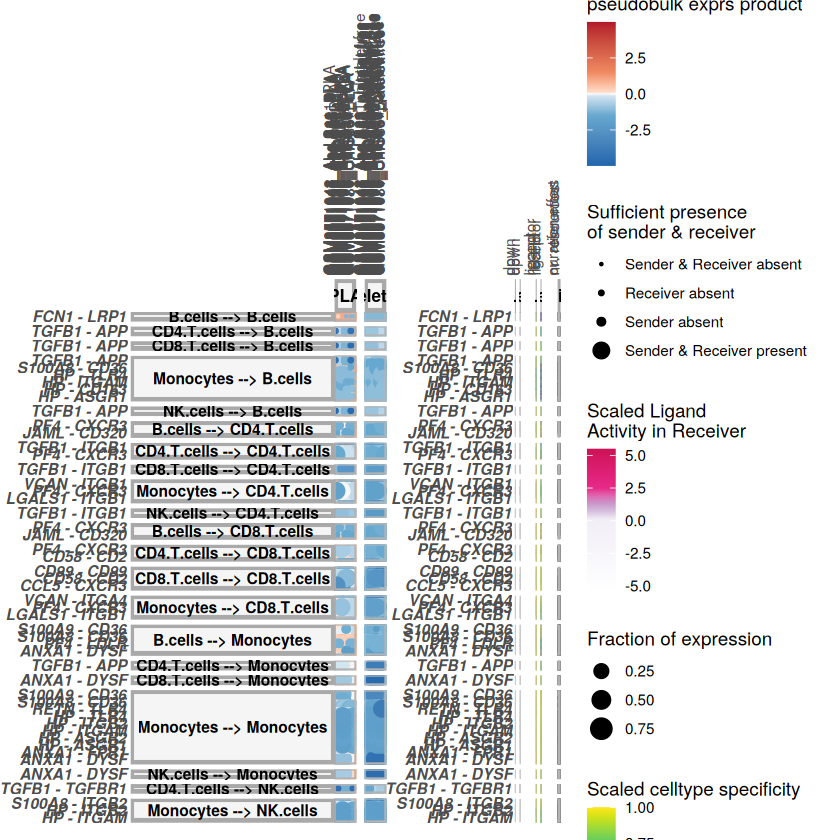

In [ ]:
prioritized_tbl_PLA_50 <- get_top_n_lr_pairs(
  multinichenet_output$prioritization_tables,
  top_n = 50,
  groups_oi = "PLA"
)

write.csv(
  prioritized_tbl_PLA_50,
  file.path(out_dir, "multinichenet_top50_PLA.csv"),
  row.names = FALSE
)

p_bubble_PLA <- make_sample_lr_prod_activity_plots_Omnipath(
  multinichenet_output$prioritization_tables,
  prioritized_tbl_PLA_50 %>% inner_join(lr_network_all, by = c("ligand", "receptor"))
)

p_bubble_PLA

ggsave(
  file.path(plot_dir, "multinichenet_top_PLA_interactions_large.png"),
  p_bubble_PLA,
  width = 24,
  height = 16,
  dpi = 300,
  limitsize = FALSE
)

Joining with `by = join_by(id)`
Joining with `by = join_by(id, sender, receiver, sender_receiver,
lr_interaction, group)`
Joining with `by = join_by(id, sender, receiver, sender_receiver,
lr_interaction, group)`
Joining with `by = join_by(receiver, sender_receiver, lr_interaction, group,
LR)`
Joining with `by = join_by(id, sender, receiver, sender_receiver,
lr_interaction, group)`
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


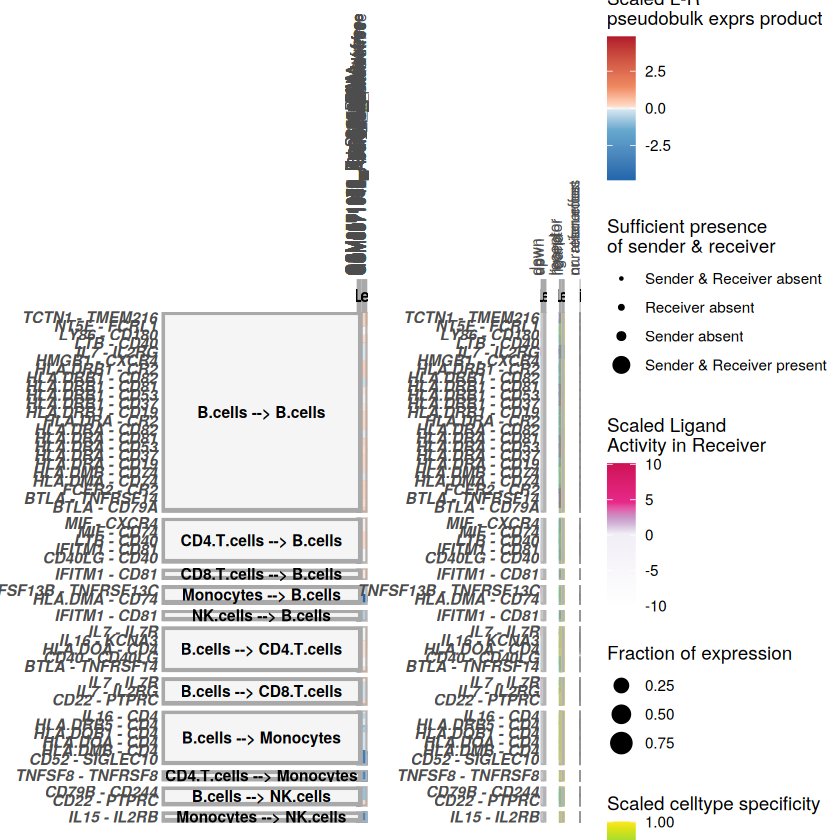

In [ ]:
prioritized_tbl_platelet_free_50 <- get_top_n_lr_pairs(
  multinichenet_output$prioritization_tables,
  top_n = 50,
  groups_oi = "platelet.free"
)

write.csv(
  prioritized_tbl_platelet_free_50,
  file.path(out_dir, "multinichenet_top50_platelet_free.csv"),
  row.names = FALSE
)

p_bubble_platelet_free <- make_sample_lr_prod_activity_plots_Omnipath(
  multinichenet_output$prioritization_tables,
  prioritized_tbl_platelet_free_50 %>% inner_join(lr_network_all, by = c("ligand", "receptor"))
)

p_bubble_platelet_free

ggsave(

  file.path(plot_dir, "multinichenet_top_platelet_free_interactions_large.png"),
  p_bubble_platelet_free,
  width = 24,
  height = 16,
  dpi = 300,
  limitsize = FALSE

)

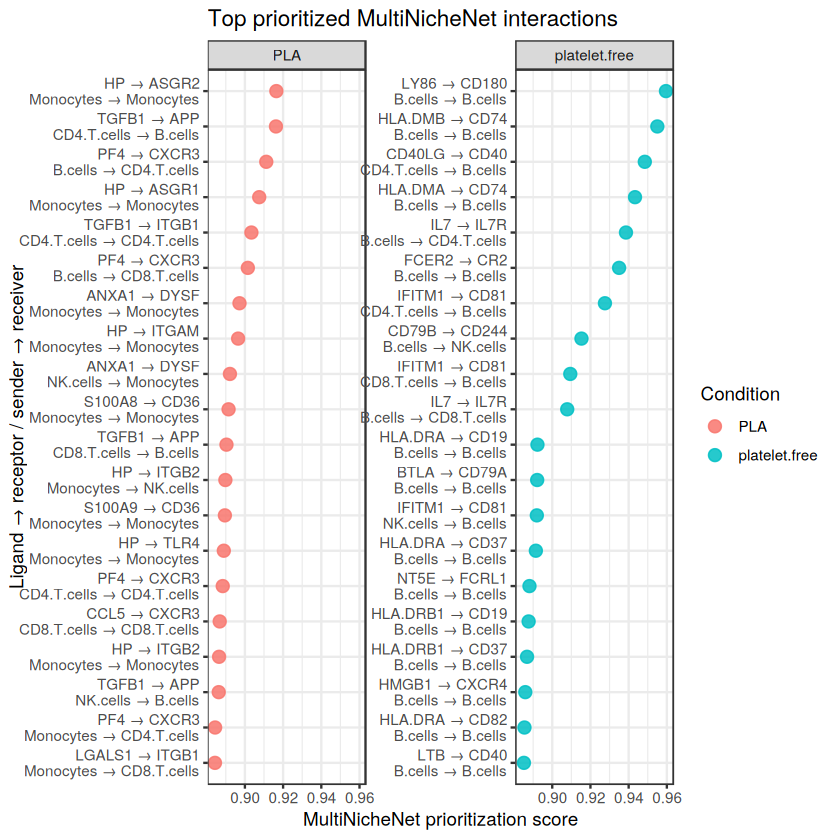

In [47]:
p_top_prioritized <- group_prioritization_tbl %>%
  filter(group %in% c("PLA", "platelet.free")) %>%
  group_by(group) %>%
  slice_max(order_by = prioritization_score, n = 20, with_ties = FALSE) %>%
  ungroup() %>%
  mutate(
    interaction = paste0(ligand, " → ", receptor),
    source_target = paste0(sender, " → ", receiver),
    label = paste0(interaction, "\n", source_target),
    label = forcats::fct_reorder(label, prioritization_score)
  ) %>%
  ggplot(aes(
    x = prioritization_score,
    y = label,
    color = group
  )) +
  geom_point(size = 3, alpha = 0.85) +
  facet_wrap(~ group, scales = "free_y") +
  theme_bw(base_size = 11) +
  labs(
    x = "MultiNicheNet prioritization score",
    y = "Ligand → receptor / sender → receiver",
    color = "Condition",
    title = "Top prioritized MultiNicheNet interactions"
  )

p_top_prioritized

ggsave(
  file.path(plot_dir, "multinichenet_top_prioritized_dotplot.png"),
  p_top_prioritized,
  width = 12,
  height = 10
)

## 16. Quick biological checks against your previous results

Look specifically for platelet/PLA-associated axes seen in scDiffCom and your custom LIANA-style mapping.

In [43]:
genes_to_check <- c(
  "PF4", "PPBP", "THBS1", "TGFB1", "CALR", "MYL9",
  "S100A8", "S100A9", "S100A12", "ANXA1",
  "LRP1", "CD36", "CXCR2", "CXCR3", "TLR2", "FPR1"
)

mnn_hits_of_interest <- group_prioritization_tbl %>%
  filter(ligand %in% genes_to_check | receptor %in% genes_to_check) %>%
  arrange(desc(prioritization_score))

head(mnn_hits_of_interest, 50)

write.csv(
  mnn_hits_of_interest,
  file.path(out_dir, "multinichenet_hits_of_interest_platelet_axes.csv"),
  row.names = FALSE
)

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PLA-platelet.free,PLA,CD4.T.cells,B.cells,TGFB1,APP,TGFB1_APP,TGFB1_APP_CD4.T.cells_B.cells,0.8148547,0.8433800,0.8990610,0.8626761,1.0010000,0.9095276,0.9270928,0.950,0.9162677,PLA
PLA-platelet.free,PLA,B.cells,CD4.T.cells,PF4,CXCR3,PF4_CXCR3,PF4_CXCR3_B.cells_CD4.T.cells,0.9991927,0.9870829,0.8603286,0.9072770,0.8791375,1.0010000,0.8850434,0.825,0.9111869,PLA
PLA-platelet.free,PLA,CD4.T.cells,CD4.T.cells,TGFB1,ITGB1,TGFB1_ITGB1,TGFB1_ITGB1_CD4.T.cells_CD4.T.cells,0.8148547,0.8433800,0.8133803,0.8796948,0.8342225,0.9095276,1.0010000,1.000,0.9034008,PLA
PLA-platelet.free,PLA,B.cells,CD8.T.cells,PF4,CXCR3,PF4_CXCR3,PF4_CXCR3_B.cells_CD8.T.cells,0.9991927,0.9870829,0.8568075,0.9254695,0.6729864,1.0010000,1.0010000,0.850,0.9015438,PLA
PLA-platelet.free,PLA,Monocytes,Monocytes,ANXA1,DYSF,ANXA1_DYSF,ANXA1_DYSF_Monocytes_Monocytes,0.8000538,0.9289559,0.8714789,0.9377934,0.6118864,1.0010000,1.0010000,1.000,0.8971712,PLA
PLA-platelet.free,PLA,NK.cells,Monocytes,ANXA1,DYSF,ANXA1_DYSF,ANXA1_DYSF_NK.cells_Monocytes,0.8065124,0.8719053,0.8714789,0.9377934,0.6118864,0.9962764,1.0010000,1.000,0.8921680,PLA
PLA-platelet.free,PLA,Monocytes,Monocytes,S100A8,CD36,S100A8_CD36,S100A8_CD36_Monocytes_Monocytes,0.8891281,0.9192680,0.8127934,0.8984742,0.5868901,1.0010000,1.0010000,1.000,0.8914537,PLA
PLA-platelet.free,PLA,CD8.T.cells,B.cells,TGFB1,APP,TGFB1_APP,TGFB1_APP_CD8.T.cells_B.cells,0.5780409,0.7125942,0.8990610,0.8626761,1.0010000,0.9378199,0.9270928,0.950,0.8903498,PLA
PLA-platelet.free,PLA,Monocytes,Monocytes,S100A9,CD36,S100A9_CD36,S100A9_CD36_Monocytes_Monocytes,0.8885899,0.9294941,0.8127934,0.8984742,0.5704766,1.0010000,1.0010000,1.000,0.8895254,PLA
